In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# List all files in your Drive root
!ls "/content/drive/My Drive/"

# List only zip files in the Drive
!ls "/content/drive/My Drive/" | grep ".zip"


'Colab Notebooks'		    vitamin_deficiency_dataa.zip
'Copy of baseline_cnn.pth'	   'Vitamin Deficiency Detection System'
 fouji.zip			    vitamin_models
'vitamin_deficiency_data (2).zip'   VQA_Project.zip
fouji.zip
vitamin_deficiency_data (2).zip
vitamin_deficiency_dataa.zip
VQA_Project.zip


In [6]:
!ls "/content/drive/My Drive/" | grep "vitamin_deficiency_data (2).zip"


vitamin_deficiency_data (2).zip


In [7]:
# Unzip only the second zip file
!unzip -q "/content/drive/My Drive/vitamin_deficiency_data (2).zip" -d "/content/vitamin_deficiency_data_2"

# Check the contents
!ls "/content/vitamin_deficiency_data_2"


vitamin_deficiency_data


In [ ]:
base_path = "/content/vitamin_deficiency_data_2/vitamin_deficiency_data"


In [10]:
import shutil
import os

# Paths
src = "/content/vitamin_deficiency_data_2/vitamin_deficiency_data"
dst = "/content/vitamin_deficiency_data_2"

# Move all contents (train, test folders) from src to dst
for item in os.listdir(src):
    s = os.path.join(src, item)
    d = os.path.join(dst, item)
    shutil.move(s, d)

# Remove the now-empty folder
os.rmdir(src)

# Check the final structure
!ls "/content/vitamin_deficiency_data_2"


angular_cheilitis  healthy_elbows  healthy_lips    hyperpigmented
bitot_spots	   healthy_eye	   healthy_mouth   phrynoderma
glossitis	   healthy_knee    healthy_tongue  ulcer


In [11]:
# Remove hyperpigmented folder
!rm -r "/content/vitamin_deficiency_data_2/hyperpigmented"

# Remove healthy_knee folder
!rm -r "/content/vitamin_deficiency_data_2/healthy_knee"


In [12]:
!ls -d /content/vitamin_deficiency_data_2/*/


/content/vitamin_deficiency_data_2/angular_cheilitis/
/content/vitamin_deficiency_data_2/bitot_spots/
/content/vitamin_deficiency_data_2/glossitis/
/content/vitamin_deficiency_data_2/healthy_elbows/
/content/vitamin_deficiency_data_2/healthy_eye/
/content/vitamin_deficiency_data_2/healthy_lips/
/content/vitamin_deficiency_data_2/healthy_mouth/
/content/vitamin_deficiency_data_2/healthy_tongue/
/content/vitamin_deficiency_data_2/phrynoderma/
/content/vitamin_deficiency_data_2/ulcer/


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [14]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])


In [15]:
import os
import shutil

base_dir = "/content/vitamin_deficiency_data_2"

# Create global train and test folders
global_train = "/content/train"
global_test = "/content/test"

os.makedirs(global_train, exist_ok=True)
os.makedirs(global_test, exist_ok=True)

classes = os.listdir(base_dir)

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    if not os.path.isdir(class_path):
        continue

    # Create class folders in global train/test
    os.makedirs(os.path.join(global_train, cls), exist_ok=True)
    os.makedirs(os.path.join(global_test, cls), exist_ok=True)

    # Move train images
    train_src = os.path.join(class_path, "train")
    if os.path.exists(train_src):
        for img in os.listdir(train_src):
            shutil.move(os.path.join(train_src, img), os.path.join(global_train, cls))

    # Move test images
    test_src = os.path.join(class_path, "test")
    if os.path.exists(test_src):
        for img in os.listdir(test_src):
            shutil.move(os.path.join(test_src, img), os.path.join(global_test, cls))

print("Dataset reorganized successfully.")


Dataset reorganized successfully.


In [22]:
!ls /content/train
!ls /content/test


angular_cheilitis  glossitis	   healthy_eye	 healthy_mouth	 phrynoderma
bitot_spots	   healthy_elbows  healthy_lips  healthy_tongue  ulcer
angular_cheilitis  glossitis	   healthy_eye	 healthy_mouth	 phrynoderma
bitot_spots	   healthy_elbows  healthy_lips  healthy_tongue  ulcer


In [23]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

train_dir = "/content/train"
test_dir  = "/content/test"

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
test_data  = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Classes: ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows', 'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue', 'phrynoderma', 'ulcer']
Train samples: 2596
Test samples: 226


In [24]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*16*16, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

num_classes = len(train_data.classes)
cnn_model = BaselineCNN(num_classes).to(device)


In [25]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.0005)
epochs = 10

from tqdm import tqdm

for epoch in range(epochs):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    train_acc = 100*correct/total
    avg_loss = total_loss/len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Train Accuracy: {train_acc:.2f}%")



Epoch 1/10 | Loss: 1.7814 | Train Accuracy: 35.79%


Epoch 2/10 | Loss: 1.0272 | Train Accuracy: 65.25%


Epoch 3/10 | Loss: 0.7991 | Train Accuracy: 75.19%


Epoch 4/10 | Loss: 0.6398 | Train Accuracy: 78.62%


Epoch 5/10 | Loss: 0.5328 | Train Accuracy: 82.09%


Epoch 6/10 | Loss: 0.4494 | Train Accuracy: 84.82%


Epoch 7/10 | Loss: 0.3873 | Train Accuracy: 87.13%


Epoch 8/10 | Loss: 0.3470 | Train Accuracy: 88.33%


Epoch 9/10 | Loss: 0.3060 | Train Accuracy: 89.56%


Epoch 10/10 | Loss: 0.2761 | Train Accuracy: 90.68%


In [26]:
cnn_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, pred = torch.max(outputs,1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"📌 Test Accuracy: {test_acc:.2f}%")


📌 Test Accuracy: 76.55%


📌 Test Accuracy: 76.55%

📌 Classification Report:

                   precision    recall  f1-score   support

angular_cheilitis       0.63      0.50      0.56        24
      bitot_spots       0.73      0.80      0.76        10
        glossitis       0.42      0.50      0.45        10
   healthy_elbows       0.60      0.82      0.69        11
      healthy_eye       0.88      0.97      0.92        37
     healthy_lips       0.83      0.86      0.84        28
    healthy_mouth       0.80      0.42      0.55        19
   healthy_tongue       0.93      0.88      0.90        16
      phrynoderma       0.85      0.88      0.86        32
            ulcer       0.71      0.74      0.72        39

         accuracy                           0.77       226
        macro avg       0.74      0.74      0.73       226
     weighted avg       0.77      0.77      0.76       226



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


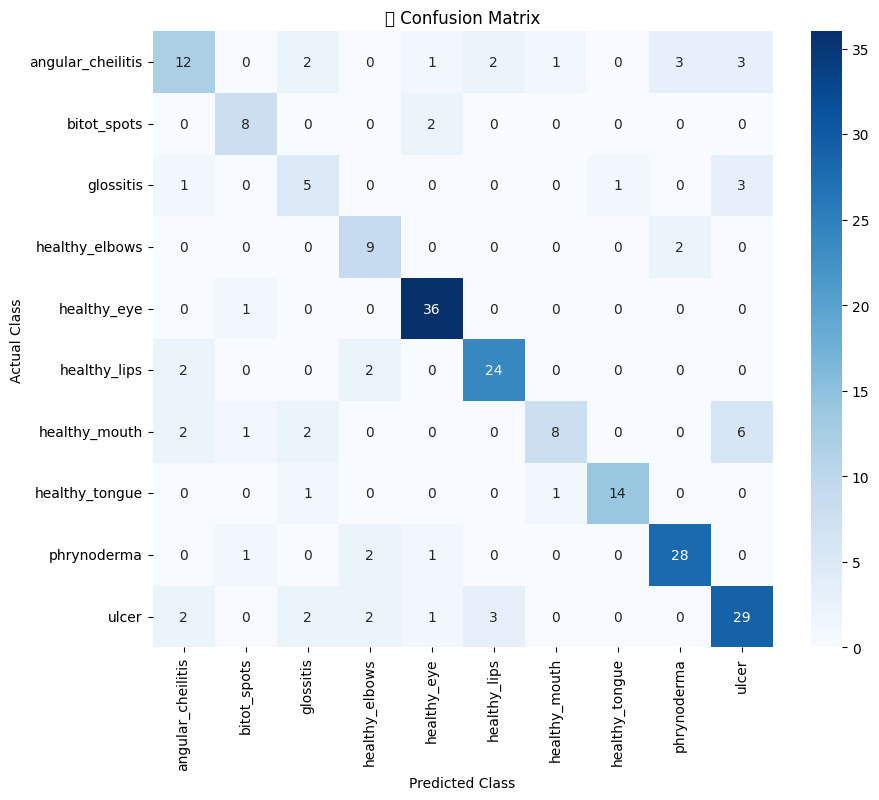

In [30]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define class names
class_names = ['angular_cheilitis', 'bitot_spots', 'glossitis', 'healthy_elbows',
               'healthy_eye', 'healthy_lips', 'healthy_mouth', 'healthy_tongue',
               'phrynoderma', 'ulcer']

# Set model to evaluation mode
cnn_model.eval()

all_preds = []
all_labels = []

# Collect predictions and true labels
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute Accuracy
test_acc = 100 * accuracy_score(all_labels, all_preds)
print(f"📌 Test Accuracy: {test_acc:.2f}%\n")

# Classification report: Precision, Recall, F1-score
report = classification_report(all_labels, all_preds, target_names=class_names)
print("📌 Classification Report:\n")
print(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("📌 Confusion Matrix")
plt.show()


In [27]:
import torch

# Path to save the full model
save_path = "/content/drive/MyDrive/cnn_model_full.pth"

# Save the entire model
torch.save(cnn_model, save_path)
print(f"✅ Full model saved to {save_path}")


✅ Full model saved to /content/drive/MyDrive/cnn_model_full.pth
